## Prepare input dataset for RLS

In [2]:
import pandas as pd
import geopandas as gpd
import datetime
from math import floor
import numpy as np

## Prepare base dataset

In [2]:
# Load files

surveys = pd.read_csv("/data/data/RLS/AODN 2024-09-17/IMOS_-_National_Reef_Monitoring_Network_Sub-Facility_-_Survey_metadata.csv", header=70, index_col = 'survey_id')
fish = pd.read_csv("/data/data/RLS/AODN 2024-09-17/IMOS_-_National_Reef_Monitoring_Network_Sub-Facility_-_Global_reef_fish_abundance_and_biomass.csv", header=70)
fish_aus = fish[fish['country'] == 'Australia']

surveys_aus = surveys[surveys['country'] == 'Australia']

/tmp/ipykernel_41814/463855929.py:4: DtypeWarning: Columns (15) have mixed types. Specify dtype option on import or set low_memory=False.
  fish = pd.read_csv("/data/data/RLS/AODN 2024-09-17/IMOS_-_National_Reef_Monitoring_Network_Sub-Facility_-_Global_reef_fish_abundance_and_biomass.csv", header=70)


In [3]:
# Fix date and time

mean_hour_flt = surveys_aus['hour'].dropna().apply(lambda x : int(x[0:2]) + int(x[3:5]) / 60).mean()
mean_hour = datetime.time(hour = floor(mean_hour_flt), minute=int(60*(mean_hour_flt-floor(mean_hour_flt))))
surveys_aus['hour'] = surveys_aus['hour'].fillna(str(mean_hour))
surveys_aus['eventDate'] = pd.to_datetime(surveys_aus['survey_date'] + ' ' + surveys_aus['hour'])

/tmp/ipykernel_41814/2450207718.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  surveys_aus['hour'] = surveys_aus['hour'].fillna(str(mean_hour))
/tmp/ipykernel_41814/2450207718.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  surveys_aus['eventDate'] = pd.to_datetime(surveys_aus['survey_date'] + ' ' + surveys_aus['hour'])


In [4]:
# Pivot table to have one row per survey.

piv = pd.pivot_table(fish_aus, index = 'survey_id', columns = 'species_name', values='biomass', aggfunc = 'sum', fill_value = 0)
piv = piv.loc[:, (piv != 0).any(axis=0)]

data = pd.merge(surveys_aus, piv, how = 'left', left_on='survey_id', right_index = True, validate='1:1')

# Drop NAs
first_species_index = list(data.columns).index('eventDate') + 1
species_columns = data.columns[first_species_index:]

data.dropna(axis=0, how='any', subset = species_columns, inplace = True)

#data.to_csv('/data/data/RLS/AODN 2024-09-17/database.csv')

## Random split

In [3]:
import numpy as np
import pandas as pd 

def mapping(x):
    if x >= 0.8:
        return('test')
    elif x >= 0.6:
        return('val')
    else:
        return('train')

In [15]:
# Split by location

ds = pd.read_csv('/data/data/RLS/AODN 2024-09-17/database-cyril.csv', index_col = 'survey_id')

locations = ds[['location']].drop_duplicates()
np.random.seed(seed = 248)
locations['rand'] = np.random.random(size = len(locations))
locations['subset'] = locations['rand'].apply(mapping)
locations.drop(columns='rand', inplace=True)
ds['survey_id'] = ds.index
ds_split = ds.merge(locations, how = 'left', left_on='location', right_on = 'location', validate='m:1')
ds_split.set_index('survey_id').to_csv('/data/data/RLS/AODN 2024-09-17/database-cyril_split.csv')

## Site metadata

In [3]:
fulldf = pd.read_csv('/marbec-data/RLS-Australia/malpolon/inputs/australia/database_common.csv',
                     index_col='survey_id',
                     dtype = {22:str, 24:str, 25:str})

In [13]:
sites = fulldf[['site_code', 'site_name', 'latitude', 'longitude', 'subset']].drop_duplicates()
sites.set_index('site_code', inplace=True)

In [26]:
def haversine(lat1, lon1, lat2, lon2):
    R = 6371
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    dlat, dlon = lat2 - lat1, lon2 - lon1
    a = np.sin(dlat/2)**2 + np.cos(lat1)*np.cos(lat2)*np.sin(dlon/2)**2
    return R * 2 * np.arcsin(np.sqrt(a))

train = sites[sites["subset"] == "train"]
test  = sites[sites["subset"] == "test"]

train_lats = train["latitude"].values
train_lons = train["longitude"].values

results = []
for _, row in test.iterrows():
    dists = haversine(row["latitude"], row["longitude"], train_lats, train_lons)
    idx = np.argmin(dists)
    results.append({
        "site_code": row.name,
        "distance_km": round(dists[idx], 1)
    })

result_df = pd.DataFrame(results)
result_df.set_index('site_code', inplace=True)
sites.loc[result_df.index, 'distance_km'] = result_df['distance_km']

sites.to_csv('/marbec-data/RLS-Australia/malpolon/inputs/australia/site_metadata.csv')

## Points map

In [37]:
import rasterio
from rasterio.plot import show as rioshow
import matplotlib.pyplot as plt
from shapely.geometry import box
import plotly.express as px

In [ ]:
ausp1 = pd.read_csv('/marbec-data/RLS-Australia/malpolon/inputs/australia/auspoints1.csv', index_col=0)
ausp1.index.name = 'survey_id'
db_td = pd.read_csv('/marbec-data/RLS-Australia/malpolon/inputs/australia/database_transductif.csv', index_col=0)

transductive_points = ausp1[ausp1.index.isin(db_td.index)]
#transductive_points.to_csv('/marbec-data/RLS-Australia/malpolon/inputs/australia/transductive_points.csv')

In [41]:
tddata = pd.read_csv('/marbec-data/RLS-Australia/malpolon/inputs/australia/transductive_points.csv',
                     index_col='survey_id', usecols=['survey_id', 'latitude', 'longitude'])
tddata['subset'] = 'Transductive'
rlsdata = pd.read_csv('/marbec-data/RLS-Australia/malpolon/inputs/australia/database_common_metadata.csv',
                      usecols=['latitude', 'longitude', 'subset'])


alldata = pd.concat([tddata, rlsdata], axis=0)
alldata = gpd.GeoDataFrame(alldata, geometry=gpd.points_from_xy(alldata.longitude, alldata.latitude), crs="EPSG:4326")

/tmp/ipykernel_195279/3094864942.py:18: UserWarning: Only specify one of 'column' or 'color'. Using 'color'.
  alldata[alldata.within(bounds)].plot(ax=ax, markersize=100, column='subset', categorical=True,


<Axes: >

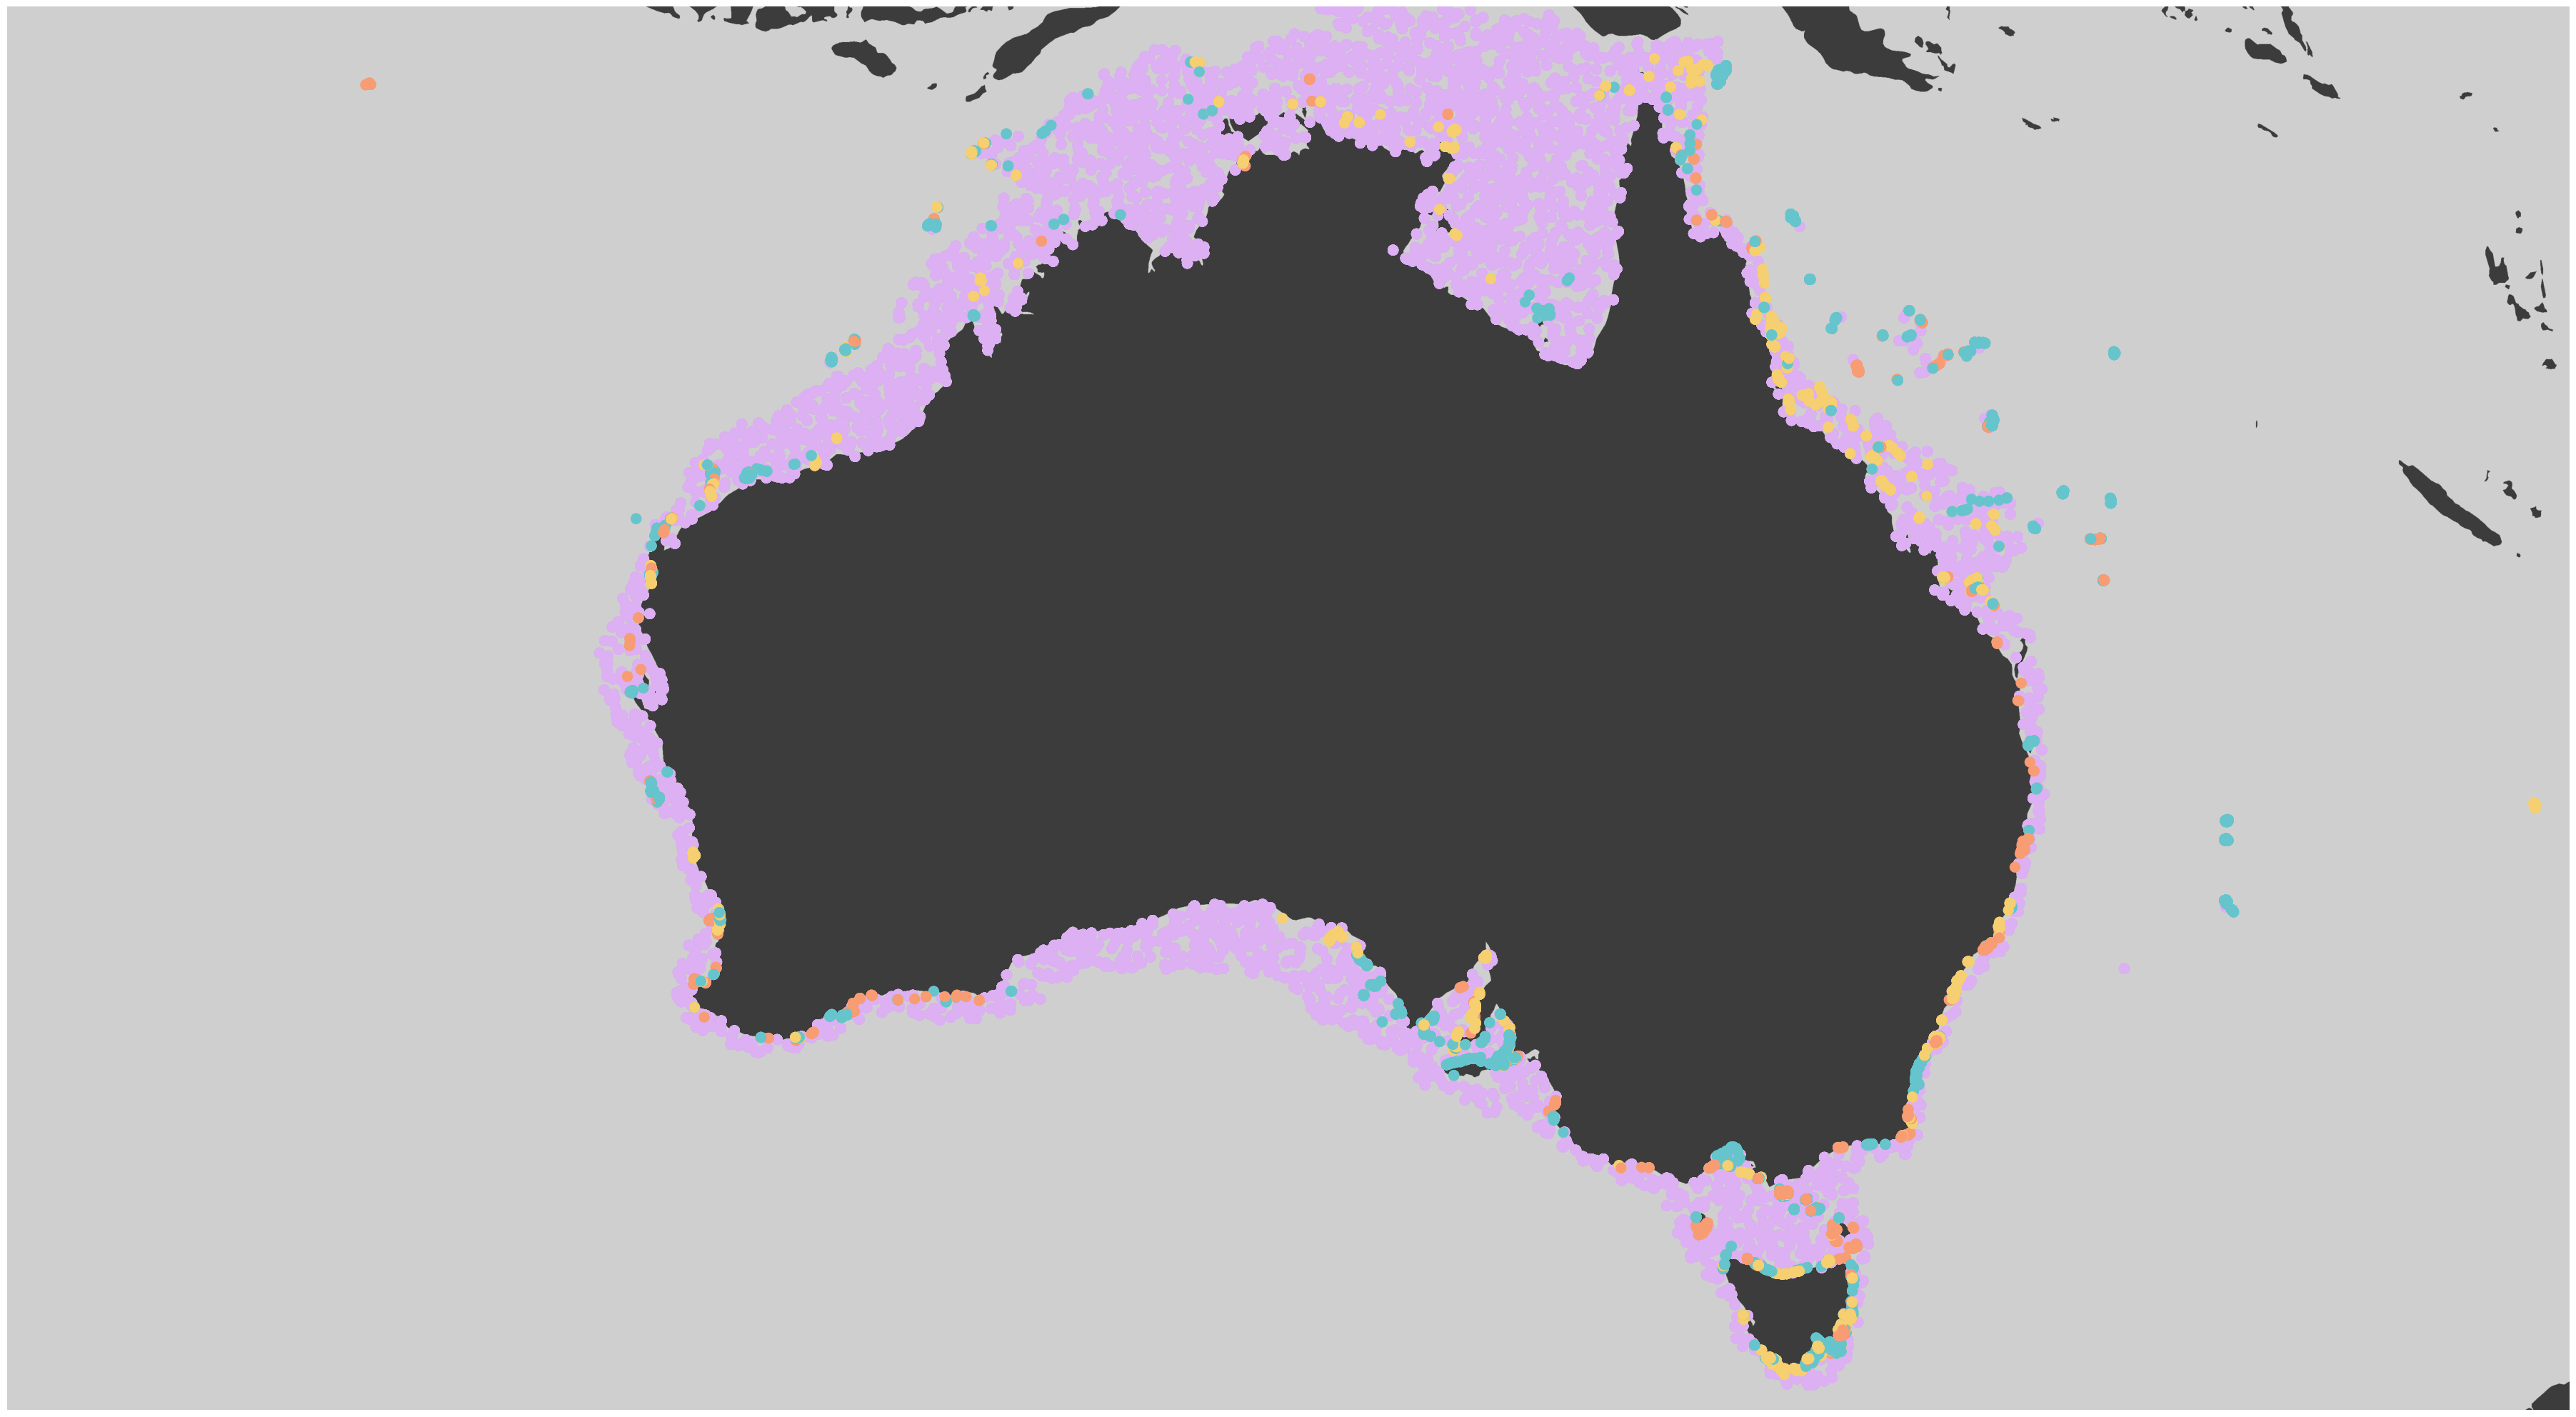

In [ ]:
colors = ['#%02x%02x%02x' % tuple(int(v) for v in c[4:-1].split(',')) for c in px.colors.qualitative.Pastel]
alldata['color'] = alldata['subset'].map({'train': colors[0], 'val': colors[1], 'test': colors[2], 'Transductive': colors[3]})

with rasterio.open('/home/gaetan/Downloads/oceans50m.tiff') as src:

    oceans = src.read(1)
    ocean_transform = src.transform
    bounds = box(*src.bounds)


fig = plt.figure(frameon=False, figsize=(40, 40 * oceans.shape[0] / oceans.shape[1]))
ax = fig.add_axes([0., 0., 1., 1.])
ax.set_axis_off()

# Plot background
rioshow(oceans, transform=ocean_transform, vmin=0, vmax = 1, cmap='gray', ax = ax)

alldata[alldata.within(bounds)].plot(ax=ax, markersize=100, column='subset', categorical=True,
                                     legend=True, color = alldata['color'],
                                     legend_kwds={'loc': 'lower left', 'fontsize': 40, 'markerscale': 4})


##  Env data PCA

In [4]:
from sklearn.decomposition import PCA

tddata = pd.read_csv('/marbec-data/RLS-Australia/malpolon/xgb/td_compound_values_mm.csv', index_col='survey_id')
rlsdata = pd.read_csv('/marbec-data/RLS-Australia/malpolon/xgb/X_compound_values_mm.csv', index_col='survey_id')
fulldf = pd.read_csv('/marbec-data/RLS-Australia/malpolon/inputs/australia/database_common.csv', index_col='survey_id')
tv_rls = rlsdata[fulldf['subset'] != 'test']
test_rls = rlsdata[fulldf['subset'] == 'test']

tddata['category'] = 'transductive'
tv_rls['category'] = 'trainval'
test_rls['category'] = 'test'

envdata = pd.concat([tddata, tv_rls, test_rls], axis=0)

pca = PCA(n_components=6)
pca.fit(envdata.drop(columns='category').fillna(0))
pca_emb = pca.transform(envdata.drop(columns='category').fillna(0))


pca_pd = pd.DataFrame(pca_emb, columns=['pc1', 'pc2', 'pc3', 'pc4', 'pc5', 'pc6'], index = envdata.index)
pca_pd['category'] = envdata['category']

/tmp/ipykernel_9034/1072944073.py:5: DtypeWarning: Columns (22) have mixed types. Specify dtype option on import or set low_memory=False.
  fulldf = pd.read_csv('/marbec-data/RLS-Australia/malpolon/inputs/australia/database_common.csv', index_col='survey_id')
/tmp/ipykernel_9034/1072944073.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  tv_rls['category'] = 'trainval'
/tmp/ipykernel_9034/1072944073.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test_rls['category'] = 'test'


In [2]:
import plotly.express as px
import plotly.graph_objects as go

pca_pd.columns = [f"PC {i+1} ({var:.1f}%)" for i, var in enumerate(pca.explained_variance_ratio_ * 100)] + ['category']

fig = px.scatter_matrix(
    pca_pd,
    dimensions=pca_pd.columns[:-1],
    color=pca_pd["category"]
)
fig.update_traces(diagonal_visible=False)
fig.update_layout(
    title="PCA of Environmental Data",
    width=1200,
    height=1200
)
fig.show()


NameError: name 'pca' is not defined

## Revisited sites

In [ ]:
fulldf = pd.read_csv('/marbec-data/RLS-Australia/malpolon/inputs/australia/database_split.csv',
                     index_col='survey_id',
                     dtype = {22:str, 24:str, 25:str})

In [22]:
visits = fulldf[['site_name', 'survey_date']].drop_duplicates()
visits['site_name'].value_counts().sort_values(ascending=False).head(60)

site_name
Halifax Park                             85
Fly Point Nelson Bay                     70
Little Beach West                        49
Pipeline                                 48
Spring Beach                             42
Central Tinderbox                        42
Auckland                                 42
Painted Cliffs South (Four Mile Reef)    41
Return Point                             41
Central, Ninepin                         40
Point Holme Lookout                      39
Darlington North                         39
Painted Cliffs                           39
Magistrates Point South                  38
Green Bluff                              38
Point Leseuer                            38
Magistrates Point North                  38
Okehampton Bay                           38
Ile du Nord                              38
Charlotte Cove Light                     37
Lucas Point                              37
Piersons Point                           37
Dennes Point          

In [16]:
fulldf.loc[fulldf['site_name'] == 'Spring Beach', 'survey_date'].drop_duplicates().sort_values()

survey_id
812303472    1992-04-07
812303481    1992-07-29
812303491    1993-06-03
812303501    1993-10-05
812303514    1994-04-21
812306911    1995-05-24
812306921    1996-04-30
812306931    1997-04-08
812306941    1997-09-17
812306951    1998-05-04
812306961    1999-04-13
812306971    1999-09-15
812306981    2000-03-20
812306991    2000-09-18
812307002    2001-04-03
812307011    2001-09-20
812307021    2002-03-06
812317651    2004-03-24
812317661    2005-02-23
812317671    2006-03-06
812317683    2006-09-19
812316701    2007-03-21
812321852    2008-03-18
812322491    2009-03-24
812323391    2010-04-27
812323611    2011-02-25
812325021    2012-04-03
812326024    2013-03-26
812326314    2014-05-08
812327011    2015-04-24
812329183    2016-04-05
812327984    2017-03-30
812331634    2018-04-05
912352784    2019-04-03
912353757    2020-03-20
923400741    2021-03-12
923401645    2022-04-06
923401936    2022-11-08
923401939    2023-01-31
923401981    2023-03-22
923402774    2023-04-21
923401

## Common species only

In [2]:
fulldf = pd.read_csv('/marbec-data/RLS-Australia/malpolon/inputs/australia/database_split.csv',
                     index_col='survey_id',
                     dtype = {22:str, 24:str, 25:str})

first_species_index = list(fulldf.columns).index('eventDate') + 1
species_columns = fulldf.columns[first_species_index:-1]

alltargets = fulldf.loc[:,species_columns]
allprev = (alltargets > 0).sum(axis=0)
rarespecies = allprev[allprev <= 50].index.to_list()

#fulldf.drop(columns=rarespecies).to_csv('/marbec-data/RLS-Australia/malpolon/inputs/australia/database_common.csv')

In [3]:
# Lognorm
bm = fulldf.drop(columns=rarespecies)

first_species_index = list(bm.columns).index('eventDate') + 1
species_columns = bm.columns[first_species_index:-1]

bm[species_columns] = np.log(1+bm[species_columns])
maxima = bm[species_columns].max()
bm[species_columns] = bm[species_columns] / maxima

#maxima.to_csv('/marbec-data/RLS-Australia/malpolon/inputs/australia/biomass_lognorm_maxima.csv')
#bm.to_csv('/marbec-data/RLS-Australia/malpolon/inputs/australia/biomass_lognorm.csv')

In [7]:
(bm[species_columns] > 0).sum().sum() / (len(bm) * len(species_columns))

0.022980118378683398

In [ ]:
fulldf = pd.read_csv('/marbec-data/RLS-Australia/malpolon/inputs/australia/database_common.csv',
                     index_col='survey_id',
                     dtype = {22:str, 24:str, 25:str})

first_species_index = list(fulldf.columns).index('eventDate') + 1
species_columns = fulldf.columns[first_species_index:-1]


bm = np.log(1+fulldf[species_columns])
print(bm[species_columns].max())
bm[species_columns] = bm[species_columns] / bm[species_columns].max()
#bm.to_csv('/marbec-data/RLS-Australia/malpolon/inputs/australia/biomass_lognorm.csv')

In [16]:
bm_tv = bm[bm['subset'] != 'test']
bm_tv['subset'] = 'test'
bm_tv.to_csv('/marbec-data/RLS-Australia/malpolon/inputs/australia/biomass_lognorm_trainval.csv')

/tmp/ipykernel_41814/901894770.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  bm_tv['subset'] = 'test'


In [4]:
# Split hard and easy files
# 
fulldf = pd.read_csv('/marbec-data/RLS-Australia/malpolon/inputs/australia/database_common_trainval.csv',
                     index_col='survey_id',
                     dtype = {22:str, 24:str, 25:str})


common_species = pd.read_csv('/marbec-data/RLS-Australia/malpolon/outputs/25_humenv_dhw_common_pa-2025-09-16_11-43-preds/all-val-f1.csv',
                     index_col=0).index.to_list()

common_easy_species = pd.read_csv('/marbec-data/RLS-Australia/malpolon/outputs/25_humenv_dhw_common_pa-2025-09-16_11-43-preds/top59-val-f1.csv',
                     index_col=0).index.to_list()

common_easyish_species = pd.read_csv('/marbec-data/RLS-Australia/malpolon/outputs/25_humenv_dhw_common_pa-2025-09-16_11-43-preds/mid111-val-f1.csv',
                     index_col=0).index.to_list()

common_hard_species = list(set(common_species) - set(common_easy_species) - set(common_easyish_species))

fulldf.drop(columns=common_easy_species).drop(columns=common_easyish_species).to_csv('/marbec-data/RLS-Australia/malpolon/inputs/australia/database_common_hard_trainval.csv')
fulldf.drop(columns=common_easy_species).drop(columns=common_hard_species).to_csv('/marbec-data/RLS-Australia/malpolon/inputs/australia/database_common_easyish_trainval.csv')
fulldf.drop(columns=common_hard_species).drop(columns=common_easyish_species).to_csv('/marbec-data/RLS-Australia/malpolon/inputs/australia/database_common_easy_trainval.csv')


## Abundance bins

In [1]:
import numpy as np
import pandas as pd 
from pathlib import Path

input_dir = Path('/marbec-data/RLS-Australia/malpolon/inputs/australia/')
ds = pd.read_csv(input_dir / 'database_common.csv', index_col = 'survey_id')

first_species_index = list(ds.columns).index('eventDate') + 1
species = ds.iloc[:, first_species_index:-1]

all_data = species.to_numpy().flatten()
nonzero = all_data[all_data != 0]

/tmp/ipykernel_11345/521221880.py:6: DtypeWarning: Columns (22) have mixed types. Specify dtype option on import or set low_memory=False.
  ds = pd.read_csv(input_dir / 'database_common.csv', index_col = 'survey_id')


In [2]:
# Calculate bins

num_bins = 10

bins = [0] + list(np.quantile(nonzero, np.linspace(0, 1, num_bins)))
bins[-1] += 1

for i in species.columns:
    ds[i] = pd.cut(ds[i], bins, include_lowest=True, labels= False, right = False)

ds.to_csv(input_dir / f"database_common_{num_bins}binned.csv")

In [3]:
# Calculate medians

new_bin_num = num_bins * 2 - 1
new_bins = [0] + list(np.quantile(nonzero, np.linspace(0, 1, new_bin_num)))

with open(input_dir / f"database_common_{num_bins}bins.txt", 'w') as f:
    for line in new_bins[::2]:
        f.write(f"{line}\n")

## Get satellite data

In [33]:
from pathlib import Path
import numpy as np
import pandas as pd
import geopandas as gpd

from geoenrich.enrichment import load_enrichment_file, add_bounds

from PIL import Image
import pystac_client
import planetary_computer

import rasterio
from rasterio import windows, features, warp
from shapely import Polygon

from tqdm.auto import tqdm
tqdm.pandas()

catalog = pystac_client.Client.open(
    "https://planetarycomputer.microsoft.com/api/stac/v1",
    modifier=planetary_computer.sign_inplace,
)

geo_buffer = 5
sat_im_path = Path('/data/data/malpolon/inputs/landsat')
time_of_interest = "2020-01-01/2021-12-31"

df, _ = load_enrichment_file('rls_aus')
geodf = add_bounds(df[['geometry']], geo_buffer, time_buff=None)

27787 occurrences were loaded from enrichment file


In [47]:
def area_of_interest(row):
    aoi = {
            "type": "Polygon",
            "coordinates": [
                [
                    [row['minx'], row['miny']],
                    [row['minx'], row['maxy']],
                    [row['maxx'], row['maxy']],
                    [row['maxx'], row['miny']],
                    [row['minx'], row['miny']],
                ]
            ],
        }
    return(aoi)


def find_best_picture(row, collection = 'sentinel-2-l2a', asset='visual'):

    aoi_bounds = features.bounds(area_of_interest(row))

    query={"eo:cloud_cover": {"lt": 10}}

    if collection == 'landsat-c2-l2':
        query['platform'] = {"in": ["landsat-8", "landsat-9"]}

    search = catalog.search(
        collections=[collection],
        bbox=aoi_bounds,
        datetime=time_of_interest,
        query=query
    )  

    items = search.item_collection()

    if(len(items)):

        gdf = gpd.GeoDataFrame.from_features(items)
        gdf['id'] = [item.id for item in items]
        gdf['asset_href'] = [item.assets[asset].href for item in items]

        aoi = Polygon(area_of_interest(row)["coordinates"][0])

        selected = gdf[gdf.contains(aoi)]

        if len(selected):
            least_cloudy_item = selected.sort_values(by = 'eo:cloud_cover', axis=0).iloc[0]
            return(least_cloudy_item['asset_href'])

    
    return(None)



def download_picture(row):

    if row['asset_href']:

        with rasterio.open(row['asset_href']) as ds:
            aoi_bounds = features.bounds(area_of_interest(row))
            warped_aoi_bounds = warp.transform_bounds("epsg:4326", ds.crs, *aoi_bounds)
            aoi_window = windows.from_bounds(transform=ds.transform, *warped_aoi_bounds)
            band_data = ds.read(window=aoi_window)

            img = Image.fromarray(np.transpose(band_data, axes=[1, 2, 0]))
            img.save(sat_im_path / f"{row.name}.jpg")


def download_picture_landsat(row):

    if row['asset_href_blue']:

        bands = []
        for color in ['red', 'green', 'blue']:

            with rasterio.open(row['asset_href_' + color]) as ds:
                aoi_bounds = features.bounds(area_of_interest(row))
                warped_aoi_bounds = warp.transform_bounds("epsg:4326", ds.crs, *aoi_bounds)
                aoi_window = windows.from_bounds(transform=ds.transform, *warped_aoi_bounds)
                band_data = ds.read(window=aoi_window)

                bands.append(band_data[0])
        
        rgb = (0.0000275*np.stack(bands, axis = -1) - 0.2).clip(min=0, max=1)
        img = Image.fromarray(np.uint8(255*rgb))
        img.save(sat_im_path / f"{row.name}.jpg")


In [ ]:

geodf2 = geodf3.iloc[0:1000]

geodf2['asset_href_blue'] = geodf2.progress_apply(find_best_picture, axis=1, args = ('landsat-c2-l2', 'blue'))
geodf2['asset_href_red'] = geodf2.progress_apply(find_best_picture, axis=1, args = ('landsat-c2-l2', 'red'))
geodf2['asset_href_green'] = geodf2.progress_apply(find_best_picture, axis=1, args = ('landsat-c2-l2', 'green'))
geodf2.progress_apply(download_picture_landsat, axis = 1)


In [38]:
# Look for missing images

sat_path = Path('/data/data/malpolon/inputs/sat')
l = []

for id in geodf.index:
    if not(Path(sat_path / f"{id}.jpg").exists()):
        l.append(id)

geodf3 = geodf.loc[l]


#### Inspect image sizes

In [27]:
file_list = list(sat_im_path.glob('*.jpg'))

d = {'w':[], 'h':[]}

for f in file_list:
    with Image.open(f) as im:
        width, height = im.size
        d['w'].append(width)
        d['h'].append(height)

df = pd.DataFrame(d)

In [28]:
df.describe()

,w,h
count,27432.000000,27432.000000
mean,1016.780548,1011.818205
std,9.332568,9.492992
min,1001.000000,995.000000
25%,1009.000000,1004.000000
50%,1016.000000,1011.000000
75%,1025.000000,1020.000000
max,1040.000000,1036.000000
